**Install Libraries**

In [1]:
!pip install numpy pandas matplotlib seaborn

**Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

In [5]:
df = pd.read_csv(r"C:\Users\bharg\OneDrive\Desktop\internship\twitter_training.csv\twitter_training.csv", header=None)
df.head()


,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


**Assign proper column names**

In [6]:
df.columns = ['ID', 'Topic', 'Sentiment', 'Text']

**Understand the Data**

In [7]:
df.head()
df['Sentiment'].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

**Data Cleaning**

In [8]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#", "", text)         # remove hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special chars
    return text

df['clean_text'] = df['Text'].apply(clean_text)

**Encode Sentiments**

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sentiment_encoded'] = le.fit_transform(df['Sentiment'])

**Count Plot**

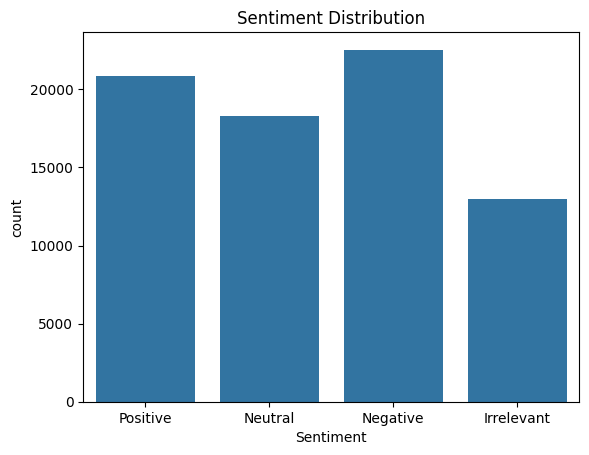

In [10]:
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

**Pie Chart**

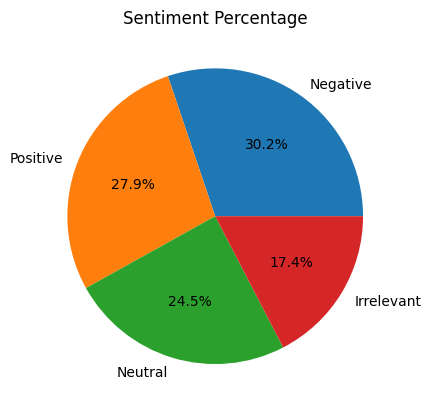

In [11]:
df['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Sentiment Percentage")
plt.show()

**Word Cloud**

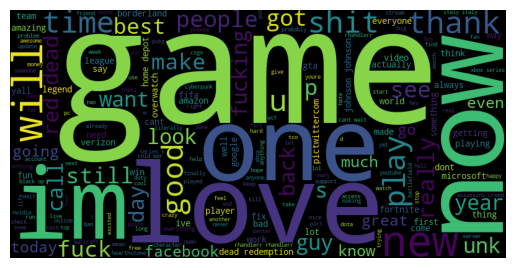

In [12]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)
plt.imshow(wc)
plt.axis('off')
plt.show()

**Word Cloud**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

X = df['clean_text']
y = df['Sentiment']

vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.80571734618732
